<a href="https://colab.research.google.com/github/chaaya139/Assignment1_Deep_learning/blob/main/Diksha_datascience_internship.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import datasets, models, layers
from sklearn.metrics import confusion_matrix

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training data shape: (60000, 28, 28), Training labels shape: (60000,)
Testing data shape: (10000, 28, 28), Testing labels shape: (10000,)


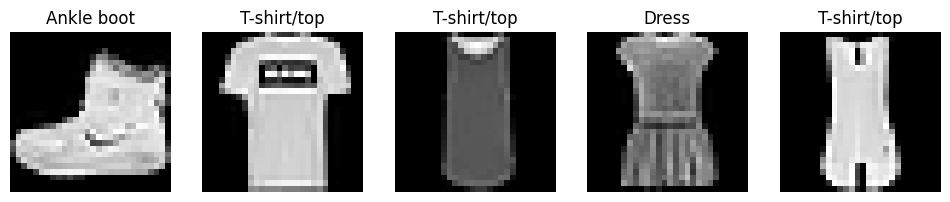

In [8]:
# Q1. Load the Fashion-MNIST dataset
# Load the dataset
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Define the class names for Fashion-MNIST
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"Training data shape: {X_train.shape}, Training labels shape: {y_train.shape}")
print(f"Testing data shape: {X_test.shape}, Testing labels shape: {y_test.shape}")

# Display the first 5 images from the training set

plt.figure(figsize=(12, 4))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')
plt.show()

In [9]:
# Q2.  Normalize and flatten the pixels
# Normalize pixel values to be between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0



In [10]:
# Q4 & 5. Build a neural network & Train it for 10 epochs
# Build the base model
base_model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)), # Flattens the 28x28 images into a 1D array of 784 pixels
    layers.Dense(128, activation='relu'), # Hidden layer 1
    layers.Dense(64, activation='relu'),  # Hidden layer 2
    layers.Dense(10, activation='softmax') # Output layer (10 classes)
])

# Compile the model
base_model.compile(optimizer='adam',
                   loss='sparse_categorical_crossentropy',
                   metrics=['accuracy'])

# Train for 10 epochs with a validation split
print("Training Base Model:")
base_history = base_model.fit(X_train, y_train, epochs=10, validation_split=0.2)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Training Base Model:
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8170 - loss: 0.5181 - val_accuracy: 0.8466 - val_loss: 0.4258
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8616 - loss: 0.3759 - val_accuracy: 0.8609 - val_loss: 0.3823
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8741 - loss: 0.3414 - val_accuracy: 0.8672 - val_loss: 0.3615
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8826 - loss: 0.3165 - val_accuracy: 0.8807 - val_loss: 0.3291
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8895 - loss: 0.2969 - val_accuracy: 0.8777 - val_loss: 0.3316
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8928 - loss: 0.2867 - val_accuracy: 0.8852 - val_loss: 0.3225
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8995 - loss: 0.2698 - val_accuracy: 0.8810 - val_loss: 0.3445
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9

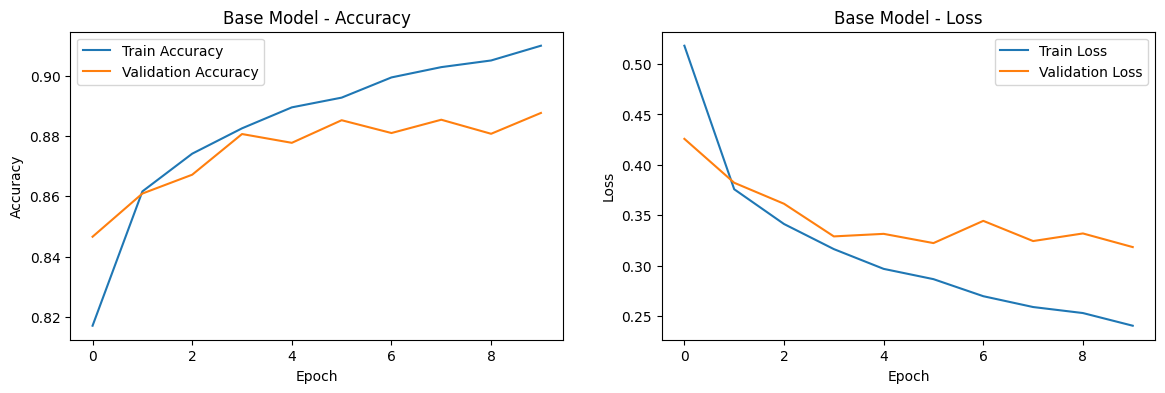

In [11]:
# Q6. Plot the loss & accuracy curves
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

    # Plot Accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title(f'{title} - Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()

    # Plot Loss
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title(f'{title} - Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()

    plt.show()

plot_history(base_history, "Base Model")

Training Dropout Model:
Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7655 - loss: 0.6595 - val_accuracy: 0.8404 - val_loss: 0.4355
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8305 - loss: 0.4732 - val_accuracy: 0.8599 - val_loss: 0.3856
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8438 - loss: 0.4339 - val_accuracy: 0.8676 - val_loss: 0.3646
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8529 - loss: 0.4100 - val_accuracy: 0.8702 - val_loss: 0.3607
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8574 - loss: 0.3973 - val_accuracy: 0.8652 - val_loss: 0.3675
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8608 - loss: 0.3853 - val_accuracy: 0.8666 - val_loss: 0.3660
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8639 - loss: 0.3743 - val_accuracy: 0.8737 - val_loss: 0.3517
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 

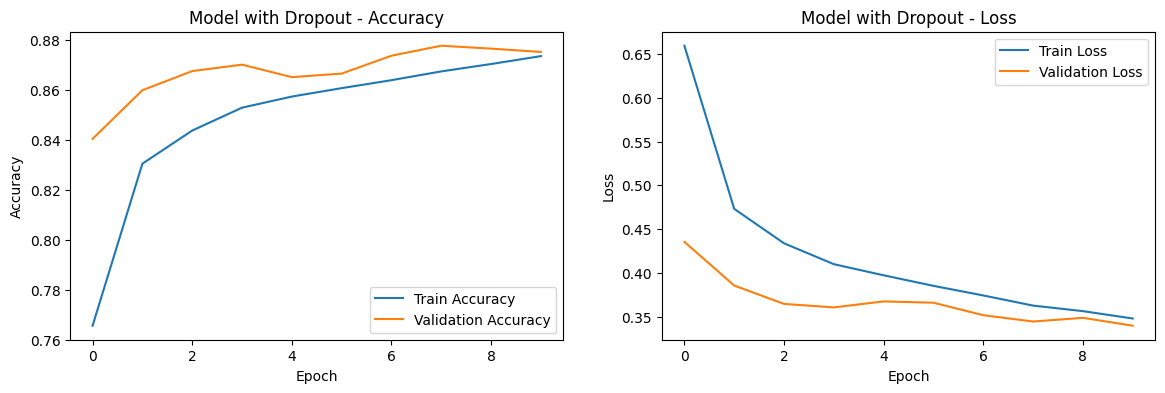

In [12]:
# Q7. Add Dropout and compare — does it reduce overfitting.

# Build model with Dropout
dropout_model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Drops 30% of neurons
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3), # Drops 30% of neurons
    layers.Dense(10, activation='softmax')
])

dropout_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

print("Training Dropout Model:")
dropout_history = dropout_model.fit(X_train, y_train, epochs=10, validation_split=0.2)

# Plot to compare
plot_history(dropout_history, "Model with Dropout")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


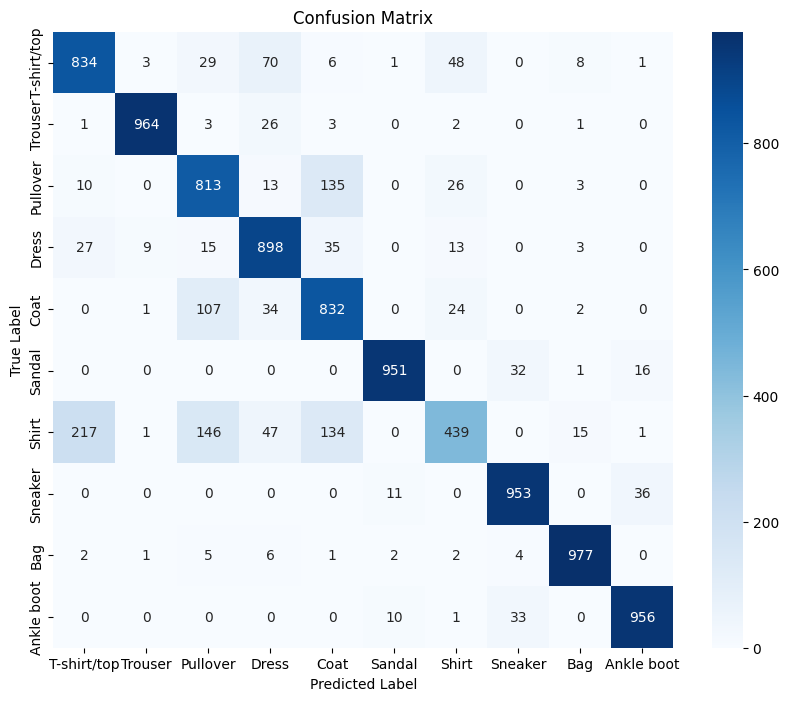

In [13]:
# Q8 Show a confusion matrix
# Make predictions on the test set
y_pred = dropout_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1) # Get the index of the highest probability

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot confusion matrix using Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

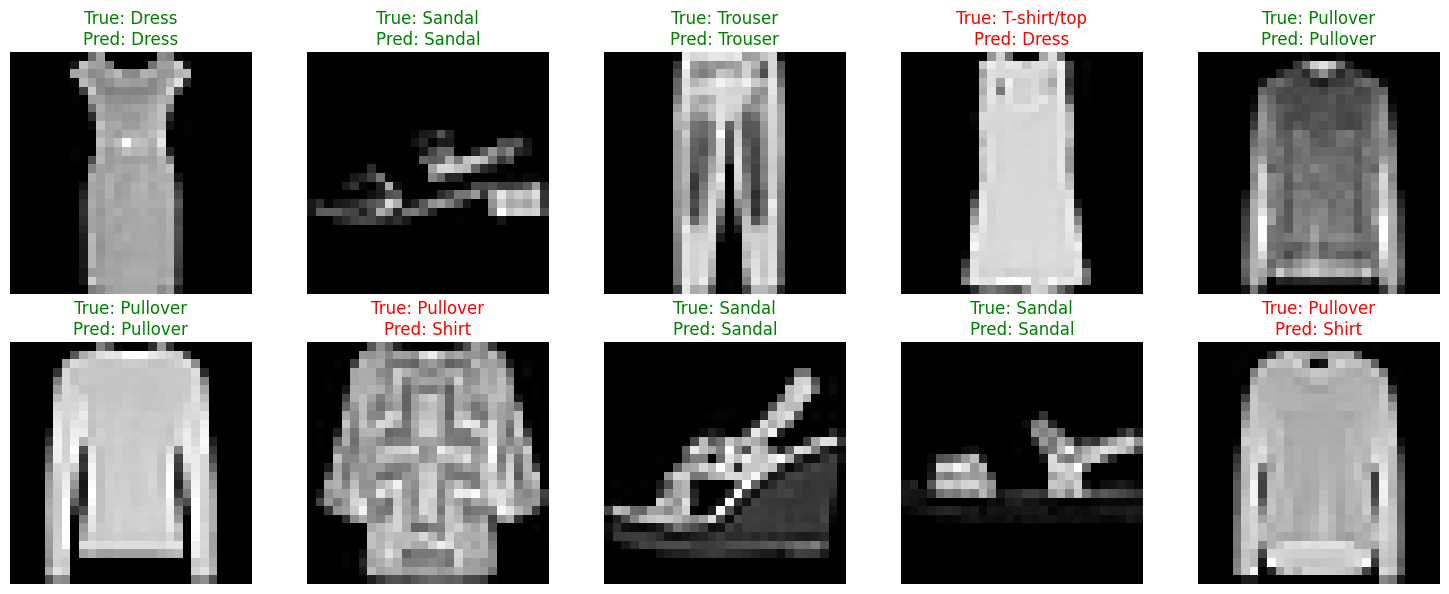

In [14]:
# Q9.  make predication on 10 images
# Select 10 random images from the test set
indices = np.random.choice(len(X_test), 10, replace=False)

plt.figure(figsize=(15, 6))
for i, idx in enumerate(indices):
    plt.subplot(2, 5, i+1)
    plt.imshow(X_test[idx], cmap='grey')

    true_label = class_names[y_test[idx]]
    predicted_label = class_names[y_pred_classes[idx]]

    # Color the title green if correct, red if incorrect
    color = 'green' if true_label == predicted_label else 'red'

    plt.title(f"True: {true_label}\nPred: {predicted_label}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()